## Potrzebne biblioteki

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

import torch
import torch.nn as nn
import torch.utils.data as data
import torch.optim as optim

import torchvision
from torchvision import transforms, datasets

## Wybór urządzenia

In [2]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

## Zbiór danych

In [3]:
transform = transforms.Compose([transforms.ToTensor()])
dataset = datasets.ImageFolder("trafic_32", transform=transform)

## Rozkład próbek w klasach

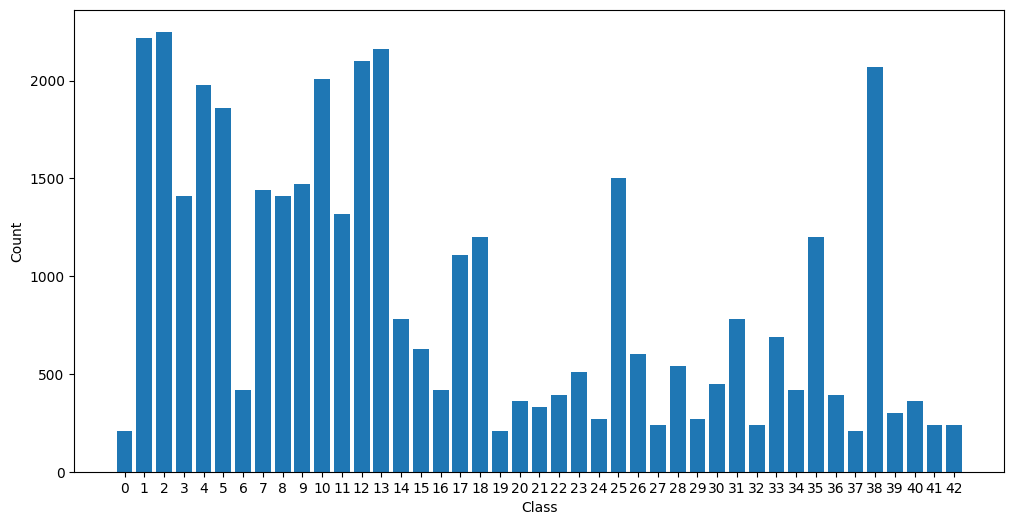

In [4]:
class_counts = Counter(dataset.targets)

classes = list(class_counts.keys())
counts = [class_counts[c] for c in classes]

plt.figure(figsize=(12, 6))
plt.bar(classes, counts)
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(classes)
plt.show()

## Ważenie próbek

In [5]:
counts = np.bincount(dataset.targets)
weights = 1.0 / counts

sample_weights = [weights[t] for t in dataset.targets]

sampler = data.WeightedRandomSampler(
    weights=sample_weights, num_samples=len(sample_weights), replacement=True
)

dataloader = data.DataLoader(dataset, batch_size=128, sampler=sampler)

## Architektura VAEGAN

In [6]:
class Encoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super(Encoder, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(input_dim, hidden_dim, 4, 2, 1),  # 16x16
            nn.LeakyReLU(0.2),
            nn.Conv2d(hidden_dim, hidden_dim * 2, 4, 2, 1),  # 8x8
            nn.BatchNorm2d(hidden_dim * 2),
            nn.LeakyReLU(0.2),
            nn.Conv2d(hidden_dim * 2, hidden_dim * 4, 4, 2, 1),  # 4x4
            nn.BatchNorm2d(hidden_dim * 4),
            nn.LeakyReLU(0.2),
        )

        self.fc_mean = nn.Linear(hidden_dim * 4 * 4 * 4, latent_dim)
        self.fc_var = nn.Linear(hidden_dim * 4 * 4 * 4, latent_dim)

    def forward(self, x):
        x = self.conv(x)
        x = torch.flatten(x, 1)

        mean = self.fc_mean(x)
        var = self.fc_var(x)
        return mean, var


def reparameterization(mean, var):
    z = mean + torch.exp(0.5 * var) * torch.randn_like(mean)
    return z

In [7]:
class Discriminator(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super(Discriminator, self).__init__()

        self.conv_1 = nn.Conv2d(input_dim, hidden_dim, 4, 2, 1, bias=False)

        self.conv_2 = nn.Conv2d(hidden_dim, hidden_dim * 2, 4, 2, 1, bias=False)
        self.bn_2 = nn.BatchNorm2d(hidden_dim * 2)

        self.conv_3 = nn.Conv2d(hidden_dim * 2, hidden_dim * 4, 4, 2, 1, bias=False)
        self.bn_3 = nn.BatchNorm2d(hidden_dim * 4)

        self.conv_out = nn.Conv2d(hidden_dim * 4, 1, 4, 1, 0, bias=False)

        self.act = nn.LeakyReLU(0.2)
        self.dropout = nn.Dropout(0.1)

    def forward(self, x):
        x = self.dropout(self.act(self.conv_1(x)))
        x = self.dropout(self.act(self.bn_2(self.conv_2(x))))
        features = self.act(self.bn_3(self.conv_3(x)))

        output = torch.sigmoid(self.conv_out(features))
        return torch.flatten(output), torch.flatten(features, 1)


class Generator(nn.Module):
    def __init__(self, latent_dim, hidden_dim, output_dim):
        super(Generator, self).__init__()

        self.conv_1 = nn.ConvTranspose2d(
            latent_dim, hidden_dim * 4, 4, 1, 0, bias=False
        )
        self.bn_1 = nn.BatchNorm2d(hidden_dim * 4)

        self.conv_2 = nn.ConvTranspose2d(
            hidden_dim * 4, hidden_dim * 2, 4, 2, 1, bias=False
        )
        self.bn_2 = nn.BatchNorm2d(hidden_dim * 2)

        self.conv_3 = nn.ConvTranspose2d(
            hidden_dim * 2, hidden_dim, 4, 2, 1, bias=False
        )
        self.bn_3 = nn.BatchNorm2d(hidden_dim)

        self.conv_4 = nn.ConvTranspose2d(hidden_dim, output_dim, 4, 2, 1, bias=False)

        self.act = nn.LeakyReLU(0.2)

    def forward(self, x):
        h = self.act(self.bn_1(self.conv_1(x)))
        h = self.act(self.bn_2(self.conv_2(h)))
        h = self.act(self.bn_3(self.conv_3(h)))

        x_hat = torch.sigmoid(self.conv_4(h))
        return x_hat

## Inicjalizacja sieci

In [8]:
latent_dim = 128
hidden_dim = 128
channels = 3
num_classes = len(dataset.class_to_idx)

encoder = Encoder(input_dim=channels, latent_dim=latent_dim, hidden_dim=hidden_dim).to(
    device
)
generator = Generator(
    latent_dim=latent_dim, hidden_dim=hidden_dim, output_dim=channels
).to(device)

discriminator = Discriminator(input_dim=channels, hidden_dim=hidden_dim).to(device)

encoder_optimizer = optim.Adam(encoder.parameters(), lr=2e-4, betas=(0.5, 0.999))
generator_optimizer = torch.optim.Adam(
    generator.parameters(), lr=4e-4, betas=(0.5, 0.999)
)
generator_scheduler = optim.lr_scheduler.ExponentialLR(
    optimizer=generator_optimizer, gamma=0.99
)
discriminator_optimizer = torch.optim.Adam(
    discriminator.parameters(), lr=1e-4, betas=(0.5, 0.999)
)
discriminator_scheduler = optim.lr_scheduler.ExponentialLR(
    optimizer=discriminator_optimizer, gamma=0.99
)

criterion = nn.BCELoss()
criterion_vae = nn.MSELoss()

## Pętla treningowa

Epoch: 0, discrimiantor fake error: 0.444, discriminator real acc: 0.533


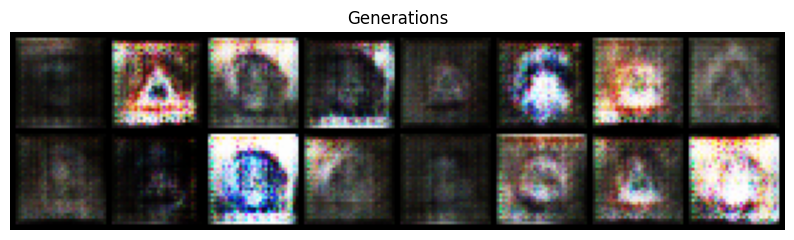

Epoch: 1, discrimiantor fake error: 0.445, discriminator real acc: 0.535
Epoch: 2, discrimiantor fake error: 0.425, discriminator real acc: 0.555
Epoch: 3, discrimiantor fake error: 0.389, discriminator real acc: 0.591
Epoch: 4, discrimiantor fake error: 0.344, discriminator real acc: 0.635
Epoch: 5, discrimiantor fake error: 0.309, discriminator real acc: 0.669
Epoch: 6, discrimiantor fake error: 0.288, discriminator real acc: 0.69
Epoch: 7, discrimiantor fake error: 0.274, discriminator real acc: 0.705
Epoch: 8, discrimiantor fake error: 0.266, discriminator real acc: 0.718
Epoch: 9, discrimiantor fake error: 0.253, discriminator real acc: 0.733
Epoch: 10, discrimiantor fake error: 0.249, discriminator real acc: 0.741


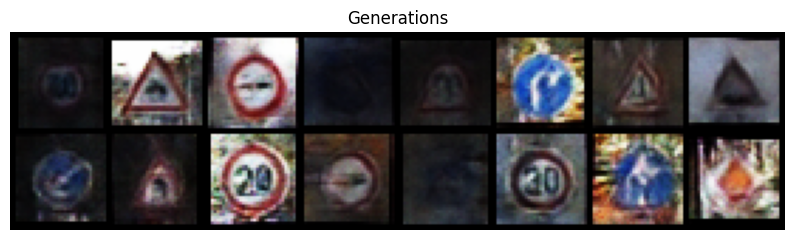

Epoch: 11, discrimiantor fake error: 0.238, discriminator real acc: 0.752
Epoch: 12, discrimiantor fake error: 0.234, discriminator real acc: 0.757
Epoch: 13, discrimiantor fake error: 0.23, discriminator real acc: 0.769
Epoch: 14, discrimiantor fake error: 0.226, discriminator real acc: 0.778
Epoch: 15, discrimiantor fake error: 0.216, discriminator real acc: 0.775
Epoch: 16, discrimiantor fake error: 0.211, discriminator real acc: 0.785
Epoch: 17, discrimiantor fake error: 0.205, discriminator real acc: 0.781
Epoch: 18, discrimiantor fake error: 0.203, discriminator real acc: 0.789
Epoch: 19, discrimiantor fake error: 0.202, discriminator real acc: 0.787
Epoch: 20, discrimiantor fake error: 0.189, discriminator real acc: 0.803


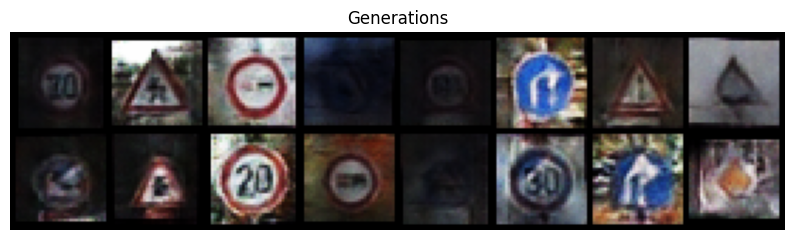

Epoch: 21, discrimiantor fake error: 0.192, discriminator real acc: 0.801
Epoch: 22, discrimiantor fake error: 0.19, discriminator real acc: 0.801
Epoch: 23, discrimiantor fake error: 0.186, discriminator real acc: 0.806
Epoch: 24, discrimiantor fake error: 0.184, discriminator real acc: 0.808
Epoch: 25, discrimiantor fake error: 0.187, discriminator real acc: 0.805
Epoch: 26, discrimiantor fake error: 0.179, discriminator real acc: 0.812
Epoch: 27, discrimiantor fake error: 0.176, discriminator real acc: 0.815
Epoch: 28, discrimiantor fake error: 0.173, discriminator real acc: 0.818
Epoch: 29, discrimiantor fake error: 0.174, discriminator real acc: 0.815
Epoch: 30, discrimiantor fake error: 0.172, discriminator real acc: 0.819


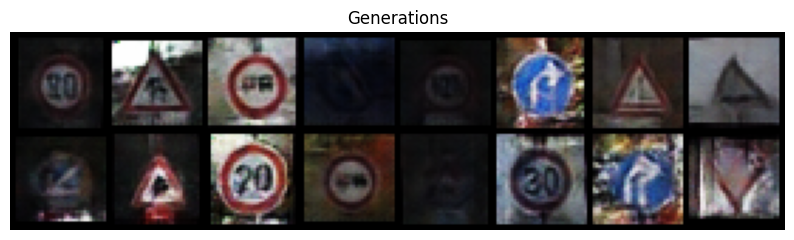

Epoch: 31, discrimiantor fake error: 0.166, discriminator real acc: 0.823
Epoch: 32, discrimiantor fake error: 0.167, discriminator real acc: 0.824
Epoch: 33, discrimiantor fake error: 0.167, discriminator real acc: 0.825
Epoch: 34, discrimiantor fake error: 0.163, discriminator real acc: 0.83
Epoch: 35, discrimiantor fake error: 0.165, discriminator real acc: 0.83
Epoch: 36, discrimiantor fake error: 0.165, discriminator real acc: 0.828
Epoch: 37, discrimiantor fake error: 0.166, discriminator real acc: 0.83
Epoch: 38, discrimiantor fake error: 0.161, discriminator real acc: 0.834
Epoch: 39, discrimiantor fake error: 0.162, discriminator real acc: 0.837
Epoch: 40, discrimiantor fake error: 0.16, discriminator real acc: 0.833


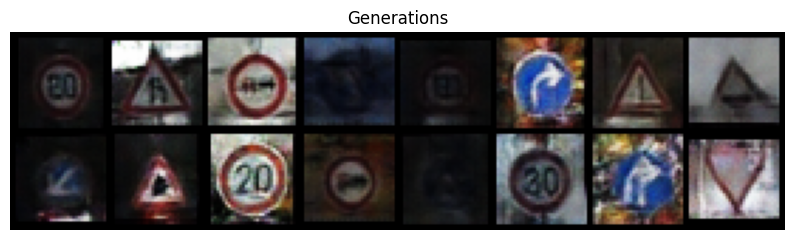

Epoch: 41, discrimiantor fake error: 0.16, discriminator real acc: 0.835
Epoch: 42, discrimiantor fake error: 0.156, discriminator real acc: 0.843
Epoch: 43, discrimiantor fake error: 0.157, discriminator real acc: 0.838
Epoch: 44, discrimiantor fake error: 0.158, discriminator real acc: 0.839
Epoch: 45, discrimiantor fake error: 0.155, discriminator real acc: 0.841
Epoch: 46, discrimiantor fake error: 0.154, discriminator real acc: 0.843
Epoch: 47, discrimiantor fake error: 0.156, discriminator real acc: 0.844
Epoch: 48, discrimiantor fake error: 0.152, discriminator real acc: 0.847
Epoch: 49, discrimiantor fake error: 0.155, discriminator real acc: 0.844
Epoch: 50, discrimiantor fake error: 0.163, discriminator real acc: 0.835


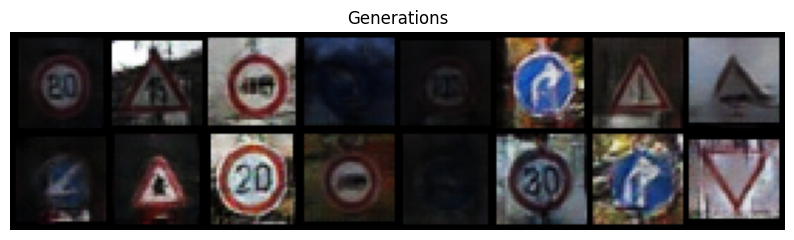

Epoch: 51, discrimiantor fake error: 0.142, discriminator real acc: 0.858
Epoch: 52, discrimiantor fake error: 0.149, discriminator real acc: 0.848
Epoch: 53, discrimiantor fake error: 0.148, discriminator real acc: 0.846
Epoch: 54, discrimiantor fake error: 0.146, discriminator real acc: 0.851
Epoch: 55, discrimiantor fake error: 0.148, discriminator real acc: 0.849
Epoch: 56, discrimiantor fake error: 0.149, discriminator real acc: 0.848
Epoch: 57, discrimiantor fake error: 0.143, discriminator real acc: 0.852
Epoch: 58, discrimiantor fake error: 0.15, discriminator real acc: 0.847
Epoch: 59, discrimiantor fake error: 0.144, discriminator real acc: 0.853
Epoch: 60, discrimiantor fake error: 0.14, discriminator real acc: 0.856


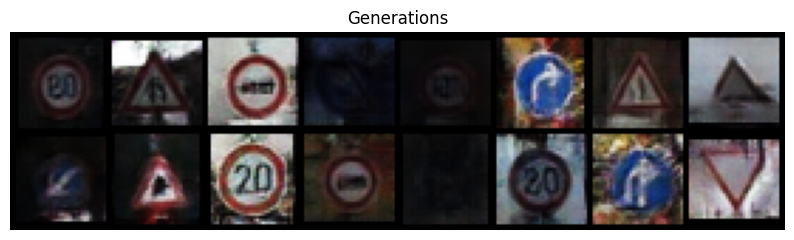

Epoch: 61, discrimiantor fake error: 0.143, discriminator real acc: 0.851
Epoch: 62, discrimiantor fake error: 0.144, discriminator real acc: 0.853
Epoch: 63, discrimiantor fake error: 0.144, discriminator real acc: 0.853
Epoch: 64, discrimiantor fake error: 0.144, discriminator real acc: 0.856
Epoch: 65, discrimiantor fake error: 0.139, discriminator real acc: 0.858
Epoch: 66, discrimiantor fake error: 0.143, discriminator real acc: 0.854
Epoch: 67, discrimiantor fake error: 0.137, discriminator real acc: 0.86
Epoch: 68, discrimiantor fake error: 0.138, discriminator real acc: 0.858
Epoch: 69, discrimiantor fake error: 0.14, discriminator real acc: 0.858
Epoch: 70, discrimiantor fake error: 0.137, discriminator real acc: 0.859


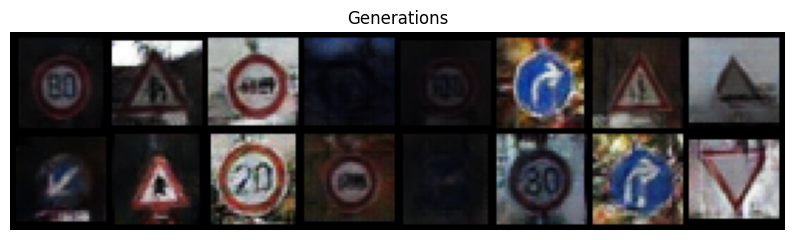

Epoch: 71, discrimiantor fake error: 0.138, discriminator real acc: 0.857
Epoch: 72, discrimiantor fake error: 0.138, discriminator real acc: 0.86
Epoch: 73, discrimiantor fake error: 0.138, discriminator real acc: 0.86
Epoch: 74, discrimiantor fake error: 0.136, discriminator real acc: 0.863
Epoch: 75, discrimiantor fake error: 0.137, discriminator real acc: 0.861
Epoch: 76, discrimiantor fake error: 0.136, discriminator real acc: 0.862
Epoch: 77, discrimiantor fake error: 0.139, discriminator real acc: 0.859
Epoch: 78, discrimiantor fake error: 0.136, discriminator real acc: 0.861
Epoch: 79, discrimiantor fake error: 0.131, discriminator real acc: 0.865
Epoch: 80, discrimiantor fake error: 0.134, discriminator real acc: 0.865


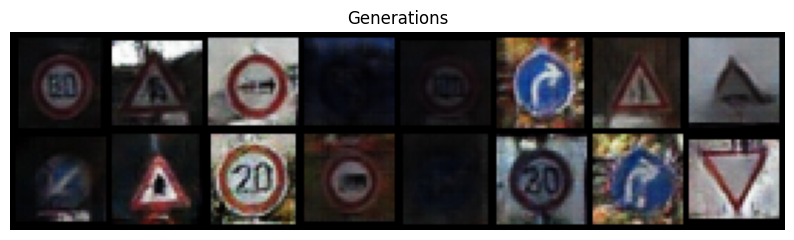

Epoch: 81, discrimiantor fake error: 0.133, discriminator real acc: 0.865
Epoch: 82, discrimiantor fake error: 0.133, discriminator real acc: 0.865
Epoch: 83, discrimiantor fake error: 0.135, discriminator real acc: 0.863
Epoch: 84, discrimiantor fake error: 0.144, discriminator real acc: 0.855
Epoch: 85, discrimiantor fake error: 0.132, discriminator real acc: 0.866
Epoch: 86, discrimiantor fake error: 0.131, discriminator real acc: 0.867
Epoch: 87, discrimiantor fake error: 0.131, discriminator real acc: 0.866
Epoch: 88, discrimiantor fake error: 0.132, discriminator real acc: 0.868
Epoch: 89, discrimiantor fake error: 0.132, discriminator real acc: 0.867
Epoch: 90, discrimiantor fake error: 0.134, discriminator real acc: 0.865


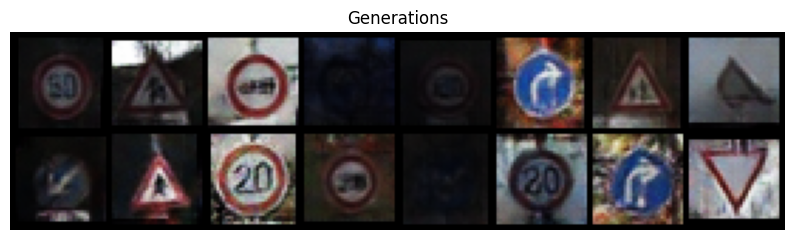

Epoch: 91, discrimiantor fake error: 0.132, discriminator real acc: 0.867
Epoch: 92, discrimiantor fake error: 0.132, discriminator real acc: 0.869
Epoch: 93, discrimiantor fake error: 0.13, discriminator real acc: 0.869
Epoch: 94, discrimiantor fake error: 0.131, discriminator real acc: 0.869
Epoch: 95, discrimiantor fake error: 0.133, discriminator real acc: 0.866
Epoch: 96, discrimiantor fake error: 0.131, discriminator real acc: 0.869
Epoch: 97, discrimiantor fake error: 0.129, discriminator real acc: 0.87
Epoch: 98, discrimiantor fake error: 0.132, discriminator real acc: 0.87
Epoch: 99, discrimiantor fake error: 0.132, discriminator real acc: 0.869


In [9]:
fixed_noise = torch.randn(16, latent_dim, 1, 1, device=device)

G_losses = []
D_losses = []
num_epochs = 100
for epoch in range(num_epochs):
    discriminator_fake_acc = []
    discriminator_real_acc = []
    for i, data in enumerate(dataloader, 0):
        ####################
        # Update D network #
        ####################

        ## Train with all-real batch
        discriminator_optimizer.zero_grad()

        real_images = data[0].to(device)
        b_size = real_images.size(0)
        label = torch.full((b_size,), 0.9, dtype=torch.float, device=device)

        output, real_features = discriminator(real_images)
        output = output.view(-1)
        error_discriminator_real = criterion(output, label)
        discriminator_real_acc.append(output.mean().item())

        ## Train with all-fake batch
        noise = torch.randn(b_size, latent_dim, 1, 1, device=device)

        fake_images = generator(noise)
        label_fake = torch.full((b_size,), 0.1, dtype=torch.float, device=device)

        output, _ = discriminator(fake_images.detach())
        output = output.view(-1)
        error_discriminator_fake = criterion(output, label_fake)
        discriminator_fake_acc.append(output.mean().item())

        # VAE
        mean, var = encoder(real_images)
        z = reparameterization(mean, var)
        vae_images = generator(z.view(b_size, latent_dim, 1, 1))
        output_vae, _ = discriminator(vae_images.detach())
        output_vae = output_vae.view(-1)
        error_discriminator_vae = criterion(output_vae, label_fake)

        error_discriminator = (
            error_discriminator_real
            + (error_discriminator_fake + error_discriminator_vae) / 2
        )
        error_discriminator.backward()

        discriminator_optimizer.step()

        ####################
        # Update G network #
        ####################
        generator_optimizer.zero_grad()
        encoder_optimizer.zero_grad()

        label = torch.ones((b_size,), dtype=torch.float, device=device)

        output, _ = discriminator(fake_images)
        output = output.view(-1)
        error_generator = criterion(output, label)

        output_vae, features_vae = discriminator(vae_images)
        output_vae = output_vae.view(-1)
        error_generator_vae = criterion(output_vae, label)
        error_vae = criterion_vae(features_vae, real_features.detach())
        error_kld = -0.5 * torch.sum(1 + var - mean.pow(2) - var.exp()) / b_size

        error_generator = (
            error_generator + error_generator_vae + error_vae + error_kld * 0.2
        )
        error_generator.backward()

        generator_optimizer.step()
        encoder_optimizer.step()

        G_losses.append(error_generator.item())
        D_losses.append(error_discriminator.item())

    print(
        f"Epoch: {epoch}, discrimiantor fake error: {np.mean(discriminator_fake_acc):.3}, discriminator real acc: {np.mean(discriminator_real_acc):.3}"
    )
    generator_scheduler.step()
    discriminator_scheduler.step()
    if epoch % 10 == 0:
        with torch.no_grad():
            fake = generator(fixed_noise).detach().cpu()
        grid = torchvision.utils.make_grid(fake)
        grid = grid.permute(1, 2, 0)
        plt.figure(figsize=(10, 10))
        plt.title(f"Generations")
        plt.imshow(grid)
        plt.axis("off")
        plt.show()

## FID

In [17]:
import os
from torchvision.utils import save_image

os.makedirs("fid_fake", exist_ok=True)
os.makedirs("fid_real", exist_ok=True)

generator.eval()
generated_imgs = []
with torch.no_grad():
    idx = 0
    for _ in range(1000 // 128 + 1):
        noise = torch.randn(128, latent_dim, 1, 1, device=device)
        imgs = generator(noise)
        for img in imgs:
            if idx >= 1000:
                break
            generated_imgs.append(img.cpu())
            save_image(img, f"fid_fake/{idx}.png")
            idx += 1

generated_imgs = torch.stack(generated_imgs[:1000])
torch.save(generated_imgs.cpu().detach(), "sroda_Pędziwiatr_Siemionek.pt")

idx = 0
for imgs, _ in dataloader:
    for img in imgs:
        save_image(img, f"fid_real/{idx}.png")
        idx += 1

In [18]:
!python -m pytorch_fid fid_real fid_fake

100%|███████████████████████████████████████████| 20/20 [02:13<00:00,  6.69s/it]
FID:  48.10358142161715
